# Telecom X - Parte 2: Predicción de Cancelación (Churn)

In [56]:
# Cargar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [57]:
# Adicionamos los colores al proyecto
ROJO_1,	ROJO_2,	ROJO_3 = "#e23155",	"#cc2c4e", "#b32742"
AZUL_1,	AZUL_2,	AZUL_3 = "#203f75",	"#1c3867", "#19325b"
BLANCO,GRIS_1, GRIS_2, GRIS_3, GRIS_4,	GRIS_5 = "#ffffff", "#ebebeb",	"#d9d9d9", "#cccccc", "#555655", "#231f20"
AQUA_1,	AQUA_2,	AQUA_3 = "#addcd4",	"#9fccc5", "#96bfb9"

# 1. Carga de datos y Análisis exploratorio

## 1. Carga de datos

In [58]:
# base de datos cargada en la nube de github
url='https://raw.githubusercontent.com/WLozanoH/TelecomX-Churn-Prediction-ML/main/Data_churn_ML'

datos = pd.read_csv(url)

## 2. Exploración inicial

In [59]:
datos.head()

,customerid,abandono,genero,clientes_senior_(>=65_años),tiene_pareja,tiene_dependientes,meses_de_contrato,servicio_telefonico,multiples_lineas_telefonicas,proveedor_de_internet,...,proteccion_de_dispositivo,soporte_tecnico,streaming_de_tv,streaming_de_peliculas,tipo_contrato,factura_electronica,forma_de_pago,cargo_mensual,cargo_total,cuentas_diarias
0,0002-orfbo,0,female,0,1,1,9,1,0,dsl,...,0,1,1,0,one year,1,mailed check,65.6,593.30,2.186667
1,0003-mknfe,0,male,0,0,0,9,1,1,dsl,...,0,0,0,1,month-to-month,0,mailed check,59.9,542.40,1.996667
2,0004-tlhlj,1,male,0,0,0,4,1,0,fiber optic,...,1,0,0,0,month-to-month,1,electronic check,73.9,280.85,2.463333
3,0011-igkff,1,male,1,1,0,13,1,0,fiber optic,...,1,0,1,1,month-to-month,1,electronic check,98.0,1237.85,3.266667
4,0013-exchz,1,female,1,1,0,3,1,0,fiber optic,...,0,1,1,0,month-to-month,1,mailed check,83.9,267.40,2.796667


## 2.1 Eliminar columnas irrelevantes
  * customerid, genero: no aporta valor al análisis o a los modelos predictivos

In [60]:
# eliminar variables irrelevantes
datos = datos.drop(columns=['customerid', 'genero'])

* Análisis de la variable objetivo
  * Gráfico de histograma con px

In [61]:
datos['abandono'].value_counts()

,count
abandono,
0,5398
1,1869


In [62]:
datos['abandono'] = datos['abandono'].apply(lambda x: 'si' if x==1 else 'no')

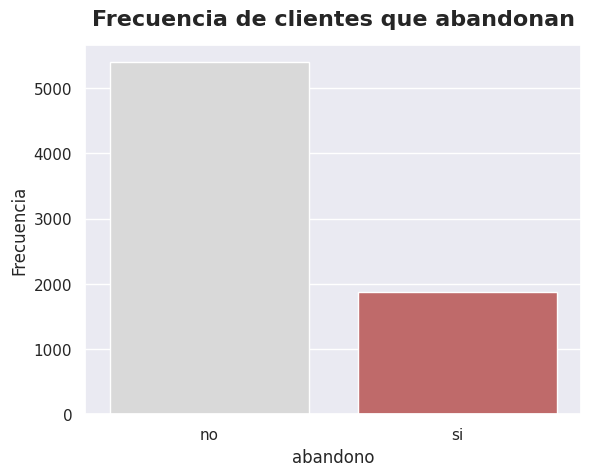

In [63]:
sns.set()
sns.countplot(datos, x='abandono', hue='abandono', palette={'no':GRIS_2, 'si':'indianred'})
plt.title('Frecuencia de clientes que abandonan', fontsize=16, fontweight='bold', y=1.03)
plt.ylabel('Frecuencia')
plt.show()

### 2.2. Análisis de variables categóricas
  * Graficar histogramas para cada variable categóricas diferenciándolo por la variable objetivo 'abandono' usando la librería plotly.
  * Columnas con más de dos clases.

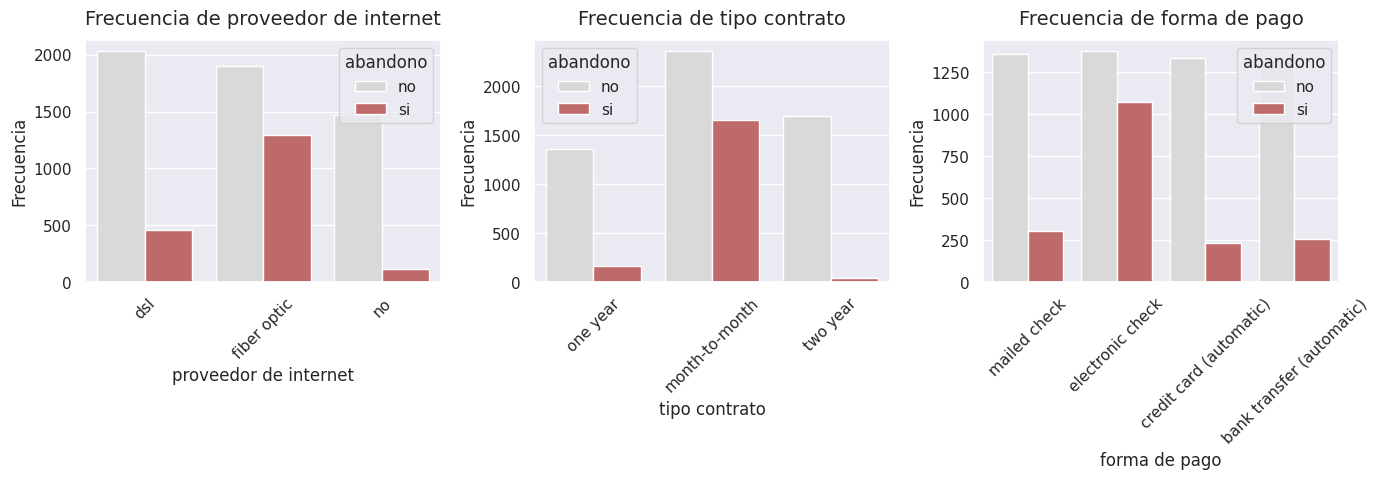

In [64]:
# variables categóricas
var_categoricas = [col for col in datos.columns if datos[col].nunique()>2 and datos[col].dtype=='object']

# iterar sobre las variables categóricas para graficar un countplot
fig, axes = plt.subplots(1,3, figsize=(14,5))

for i, var in enumerate(var_categoricas):
    sns.set()
    sns.countplot(data=datos, x=var, hue='abandono', palette={'no':GRIS_2, 'si':'indianred'}, ax=axes[i])
    axes[i].set_title(f'Frecuencia de {var.replace("_", " ")}', fontsize=14, y=1.03)
    axes[i].set_ylabel('Frecuencia')
    axes[i].set_xlabel(f'{var.replace("_", " ")}')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 2.3. Análisis de variables categóricas(binarias)
  * Graficar histogramas para cada variable categóricas diferenciándolo por la variable objetivo 'abandono' usando la librería seaborn.
  * Columnas con sólo dos clases.

In [65]:
# columnas binarias y diferente de abandono y genero
var_binarias = [col for col in datos.columns if col != 'abandono' and datos[col].nunique() == 2 and col != 'genero']
var_binarias

['clientes_senior_(>=65_años)',
 'tiene_pareja',
 'tiene_dependientes',
 'servicio_telefonico',
 'multiples_lineas_telefonicas',
 'seguridad_en_linea',
 'respaldo_en_linea',
 'proteccion_de_dispositivo',
 'soporte_tecnico',
 'streaming_de_tv',
 'streaming_de_peliculas',
 'factura_electronica']

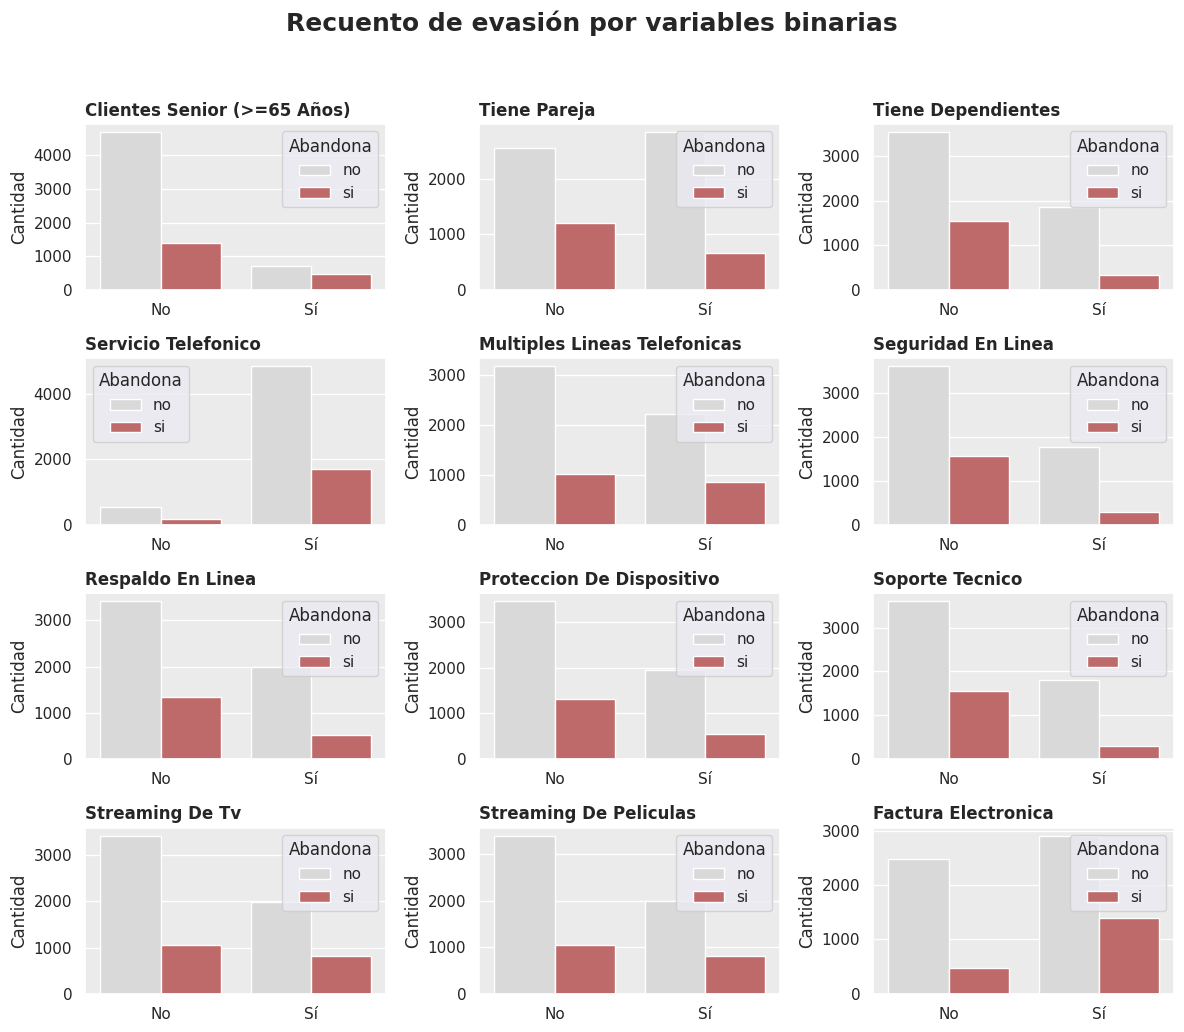

In [66]:
# Iterar y graficar todas las variables binarias en un grafico de boxplot
# Crear figura con 3 filas y 4 columnas
fig, axes = plt.subplots(4,3,figsize=(12,10))
plt.subplots_adjust(hspace=0.5, wspace=0.3)
fig.suptitle('Recuento de evasión por variables binarias', fontsize=18, fontweight='bold', y=1.03)
axes = axes.flatten() # Aplanar array de ejes

# Recorrer las variables y graficar:
for i, var in enumerate(var_binarias):
  ax = axes[i]
  sns.countplot(data=datos, x=var, hue='abandono', ax=ax, palette={'no': GRIS_2, 'si': 'indianred'})

  # Convertir var a formato legible: reemplazar "_" y poner formato título
  titulo = var.replace("_", " ").title()
  ax.set_title(titulo, fontsize=12, loc='left', fontweight='bold')

  ax.set_ylabel('Cantidad')
  ax.set_xlabel('') # Quitar etiquetas del eje X
  ax.set_xticklabels(['No', 'Sí']) #Porque son variables binarias

# Estilo de fondo
  ax.set_facecolor(GRIS_1)
  ax.patch.set_color(GRIS_1)

# Cambiar etiquetas de la leyenda
  handles, labels = ax.get_legend_handles_labels()
  ax.legend(handles=handles, labels=['no', 'si'], title='Abandona')

# Ocultar subplots vacíos si hay más o menos variables binarias
for j in range(len(var_binarias), len(axes)):
    fig.delaxes(axes[j])

#Ajustar y mostrar el gráfico
plt.tight_layout()
plt.show()

### 2.4. Análisis de variables numéricas
  * Graficar boxplot para cada variable numérica diferenciándolo por la variable objetivo 'abandono' usando la librería plotly.

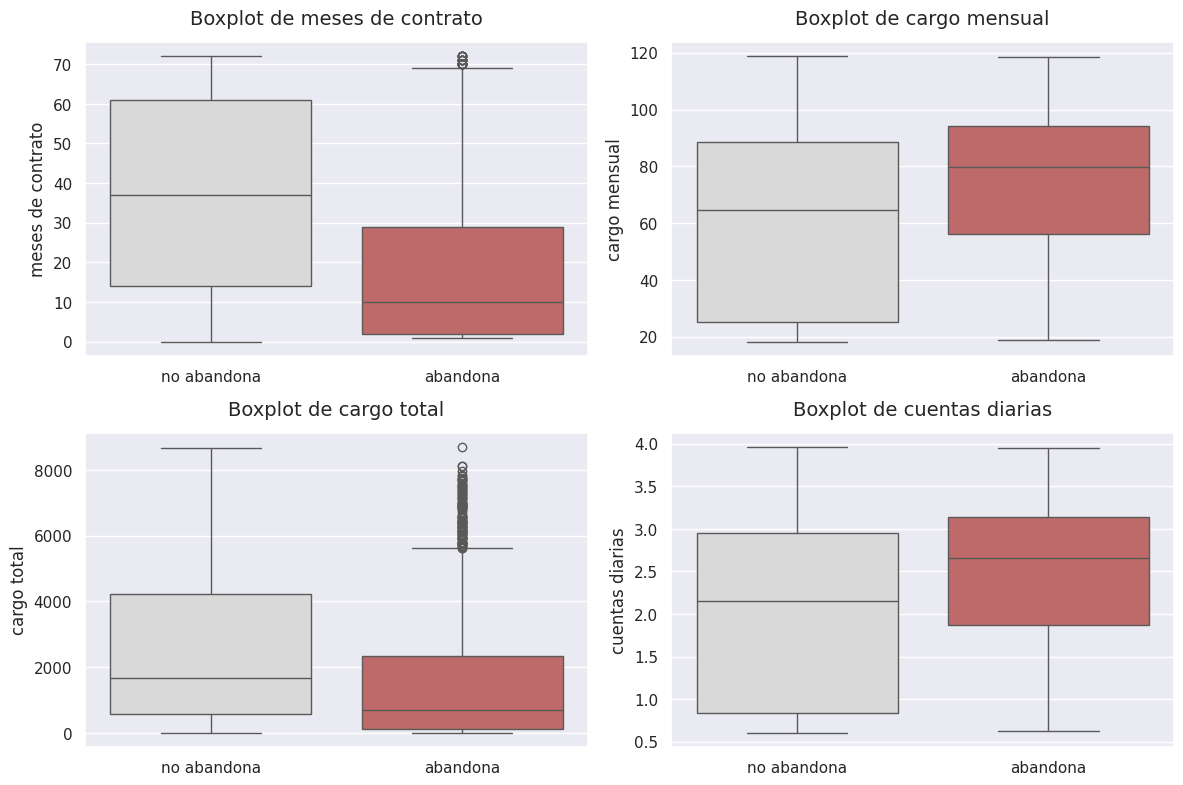

In [67]:
# Seleccionar solo las variables numéricas
var_numericas = [col for col in datos.select_dtypes(include='number').columns if col != 'abandono' and datos[col].nunique() !=2]

sns.set()
fig, axes = plt.subplots(2,2, figsize=(12,8))
plt.subplots_adjust(hspace=0.4)

axes = axes.flatten() # aplanar los ejes


for i, var in enumerate(var_numericas):
    sns.set()
    sns.boxplot(data=datos, x='abandono', y=var, palette={'no': GRIS_2, 'si': 'indianred'}, ax=axes[i])
    axes[i].set_title(f'Boxplot de {var.replace("_", " ")}', fontsize=14, y=1.03)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['no abandona', 'abandona'])
    axes[i].set_ylabel(f'{var.replace("_", " ")}')
plt.tight_layout()
plt.show()

* Usaré los datos de clientes que pagan solo hasta 8600

In [68]:
print(f'Filas antes: {datos.shape[0]}')
# pocos outliers mayores a 8600, los eliminamos
datos = datos[datos['cargo_total'] < 8600]
print(f'Filas después: {datos.shape[0]}')

Filas antes: 7267
Filas después: 7264


# 2. Separación entre variables y objetivo

Antes de predecir un modelo con machine learning, es importante separar los datos en dos partes:
* y: **la variable objetivo**, es decir, lo que queremos predecir(por ejemplo: si un cliente abandona o no)
* X: **las variables explicativas**, que son los datos o características que usaremos para hacer la predicción (como genero, tipo de contrato, cargo total, etc)

In [69]:
from sklearn.model_selection import train_test_split

# Separando los datos en X e y
X = datos.drop(columns='abandono')  # tu variable objetivo
y = datos['abandono']

# 3. Separación de datos en entrenamiento y prueba

In [70]:
# Convertir y a valores numéricos (1/0) con LabelEncoder
from sklearn.preprocessing import LabelEncoder

# instanciar LabelEncoder
LabelEncoder = LabelEncoder()

# Ajustar y transformar la variable objetivo
y_encoded = LabelEncoder.fit_transform(y)

# Dividir datos: 80% entrenamiento, 20% prueba
X, X_test, y, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# 4. Preprocesamiento

## 4.1. Transformando las variables explicativas

Los algoritmos de machine learning no entienden texto, solo números. Por eso, necesitamos convertir los datos de texto en números. Pero esta conversión debe hacerse con cuidado, sin cambiar el significado original de los datos. No se trata solo de poner cualquier número al azar.

### Encoding:
  * Codificación de las variables categóricas a formato numérico para hacerlas compatibles con modelos de machine learning.
    * Usar: **OneHotEncoder**
      * OneHotEncoder: transforma los valores de las columnas en 0 y 1 en un array
      * Dado que se integra con **pipelines** y lo usaremos para el flujo de trabajo

    * Usar: **Column_transformer**
      * Es una clase más flexible y explícita que **make_column_transformer**.
      * Permite nombrar los pasos manualmente.
      * Es más clara para pipelines grandes o cuando quieres control más detallado.

In [71]:
# importar librerías
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Detectar columnas
num_cols = [col for col in X.select_dtypes(include='number').columns if X[col].nunique() !=2] # columnas numéricas
cat_cols = [col for col in X.select_dtypes(include='object').columns if X[col].nunique() >2] # columnas categóricas
bin_cols = [col for col in X.select_dtypes(include='number').columns if X[col].nunique()==2] # columnas binarias

# Preprocesador
preprocesador = ColumnTransformer(transformers=[

    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('bin', 'passthrough', bin_cols)

])


## 4.1. Transformando la variable respuesta (objetivo)

Al igual que las variables explicativas, la variable objetivo también debe estar en formato numérico. Si es binaria (dos categorías), podemos representarla con 0 y 1:

0 = no tiene la característica
1 = sí la tiene
LabelEncoder: Uso principal, codificar la variable objetivo(y)

para clasificación multiclase o binaria
Ya la transformamos al inicio, antes de separar los datos en entrenamiento y prueba

## 5. Modelo de referencia - Baseline

* Es el modelo más simple que se puede usar. Consiste en predecir siempre la clase que más se repite en los datos (por ejemplo, siempre decir que un cliente no abandona si esa es la mayoría).
* Por defecto predice el valor previo.(prior)

* Este modelo no usa ningún algoritmo complejo, pero sirve como punto de comparación: si un modelo más avanzado no mejora este resultado, entonces no está haciendo bien su trabajo.

* Siempre se usa un clasificador dummy.

✅ Esto nos da una métrica mínima que cualquier modelo debe superar.

In [72]:
# importar la libreria
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report

# instanciar el modelo dummy
dummy = DummyClassifier() # por defecto 'strategy' = 'prior'

# entrenar el modelo con dummy
dummy.fit(X, y) # entrena con los datos de entrenamiento

# probar en los datos de prueba
score_dummy = dummy.score(X_test, y_test) # evalúa con accuracy: exactitud
print(f'Accuracy del modelo dummy: {score_dummy:.4f}')

y_predict_dummy = dummy.predict(X_test) # predicciones

# metricas para dummy
print(f'\nResumen de métricas para modelo base -dummy:\n\n {classification_report(y_test, y_predict_dummy)}')

Accuracy del modelo dummy: 0.7385

Resumen de métricas para modelo base -dummy:

               precision    recall  f1-score   support

           0       0.74      1.00      0.85      1073
           1       0.00      0.00      0.00       380

    accuracy                           0.74      1453
   macro avg       0.37      0.50      0.42      1453
weighted avg       0.55      0.74      0.63      1453



# 6. Análisis de correlación

## 6.1. Datos preprocesados para la correlación

In [73]:
# Obtener datos preprocesados
X_procesado = preprocesador.fit_transform(X)

# Unir con la variable objetivo

X_procesado_df = pd.DataFrame(X_procesado.toarray() if hasattr(X_procesado, 'toarray') else X_procesado, columns = preprocesador.get_feature_names_out())
#X_procesados = pd.DataFrame(X_procesados, columns=preprocesador.get_feature_names_out())
X_procesado_df['abandono'] = y
X_procesado_df.head()

,num__meses_de_contrato,num__cargo_mensual,num__cargo_total,num__cuentas_diarias,cat__proveedor_de_internet_dsl,cat__proveedor_de_internet_fiber optic,cat__proveedor_de_internet_no,cat__tipo_contrato_month-to-month,cat__tipo_contrato_one year,cat__tipo_contrato_two year,...,bin__servicio_telefonico,bin__multiples_lineas_telefonicas,bin__seguridad_en_linea,bin__respaldo_en_linea,bin__proteccion_de_dispositivo,bin__soporte_tecnico,bin__streaming_de_tv,bin__streaming_de_peliculas,bin__factura_electronica,abandono
0,0.354006,-0.302115,-0.019222,-0.302115,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0
1,-0.744235,0.677965,-0.504773,0.677965,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1
2,0.028601,-1.470225,-0.703242,-1.470225,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,1.126842,-0.500128,0.348538,-0.500128,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0
4,-0.256128,-1.481872,-0.790020,-1.481872,0.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0


## 6.2. 📈 Calcular la matriz de correlación

In [74]:
# Calcular Matriz de correlación
correlacion_matrix = X_procesado_df.corr()

# Reemplazar _ por espacio en las columnas e índice
correlacion_matrix.columns = correlacion_matrix.columns.str.replace('_', ' ')
correlacion_matrix.index = correlacion_matrix.index.str.replace('_', ' ')

## 6.3. 🎨 Visualizar la matriz con una máscara triangular

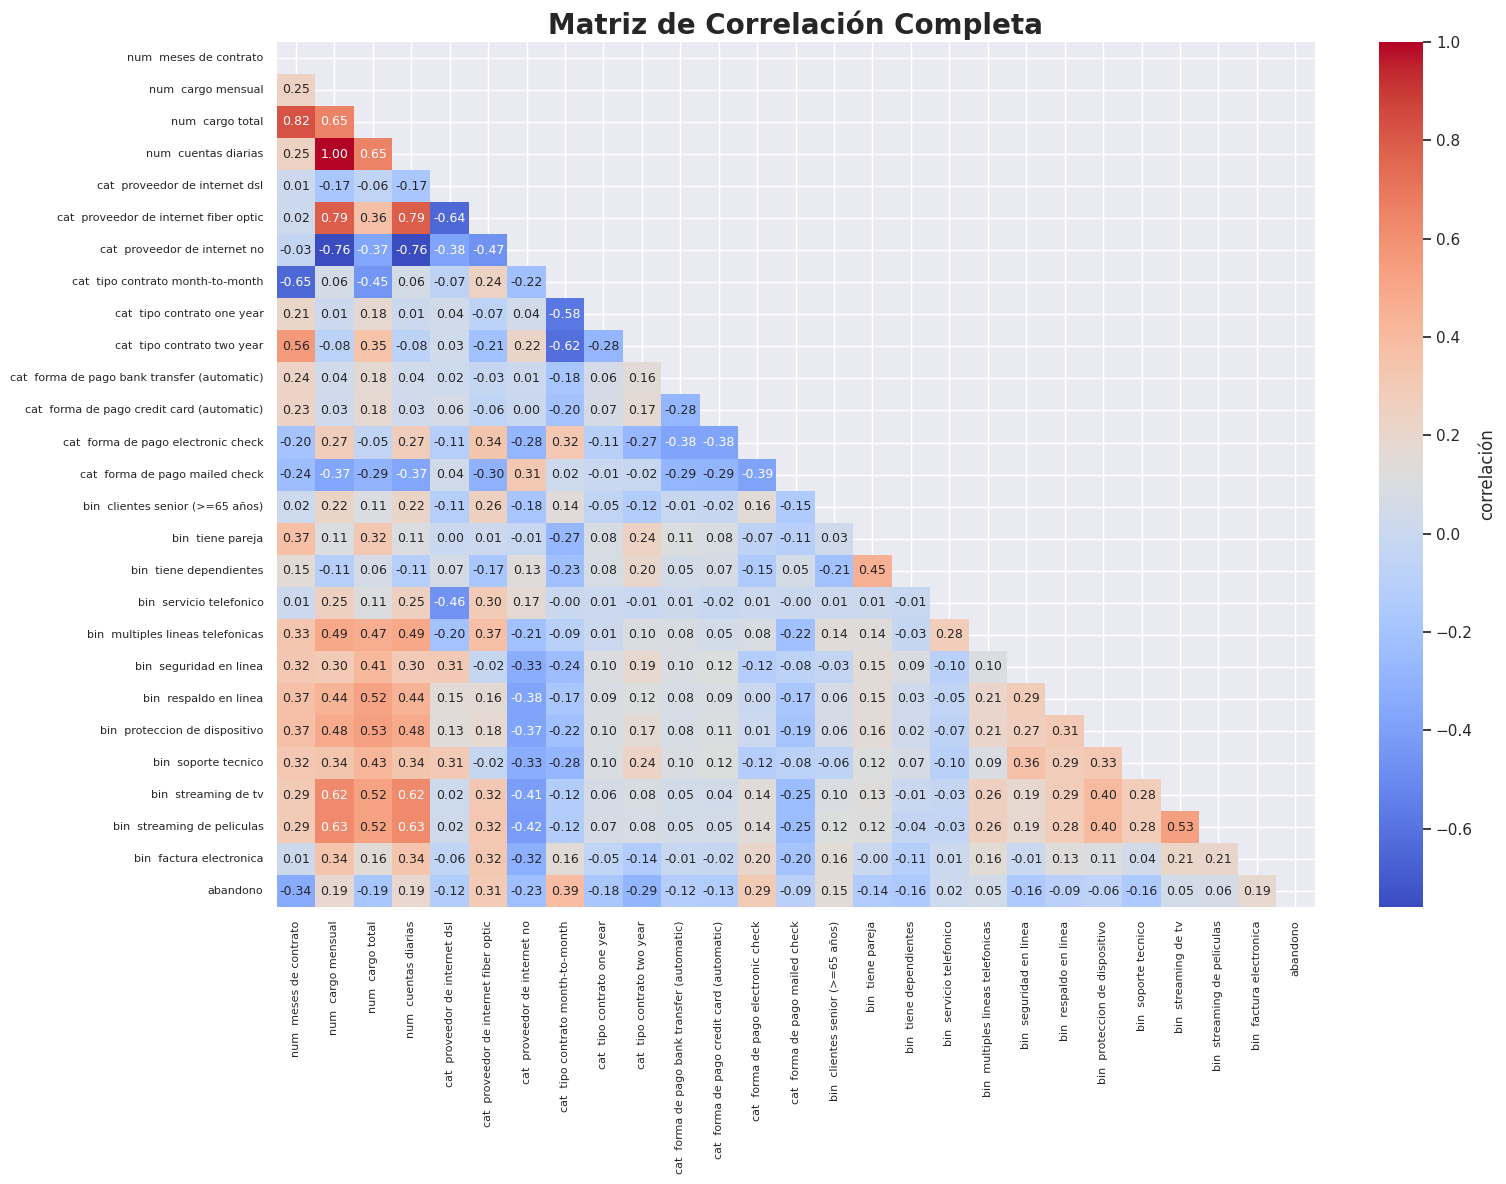

In [75]:
# Crear máscara para ocultar la mitad superior
mascara = np.triu(np.ones_like(correlacion_matrix, dtype='bool'))

# Gráfico de calor
plt.figure(figsize=(16,12))
sns.heatmap(correlacion_matrix, mask=mascara, cmap='coolwarm', annot=True, fmt='.2f',
            annot_kws={"size": 9},
            cbar_kws={"label": "correlación"}

            )
plt.title('Matriz de Correlación Completa', fontsize=20, fontweight='bold')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

In [76]:
# Correlación con la variable 'abandono'
correlaciones = correlacion_matrix['abandono'].sort_values(ascending=False)
print(correlaciones)

abandono                                        1.000000
cat  tipo contrato month-to-month               0.390383
cat  proveedor de internet fiber optic          0.305501
cat  forma de pago electronic check             0.292310
num  cargo mensual                              0.192684
num  cuentas diarias                            0.192684
bin  factura electronica                        0.185705
bin  clientes senior (>=65 años)                0.148081
bin  streaming de peliculas                     0.063067
bin  multiples lineas telefonicas               0.048122
bin  streaming de tv                            0.046370
bin  servicio telefonico                        0.021087
bin  proteccion de dispositivo                 -0.063449
cat  forma de pago mailed check                -0.088752
bin  respaldo en linea                         -0.089784
cat  forma de pago bank transfer (automatic)   -0.116810
cat  proveedor de internet dsl                 -0.124870
cat  forma de pago credit card 

# 7. Análisis Dirigido

Investigar variables específicas se relacionan con la cancelación, tales como:

* Tiempo de contrato × Cancelación
* Gasto total × Cancelación

Utilizar gráficos como boxplots o scatter plots para visualizar patrones y posibles tendencias.

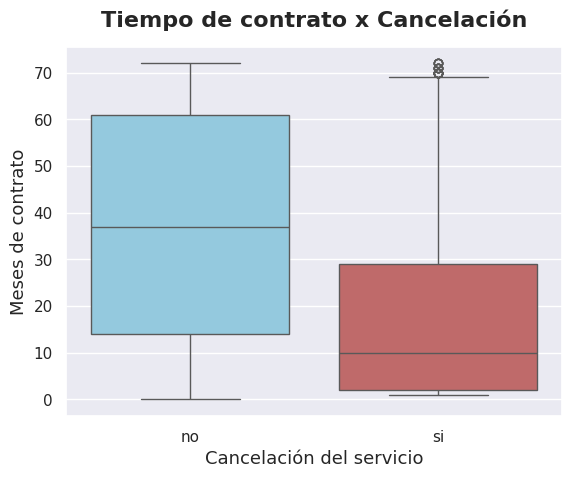

In [77]:
# Gráfico de Tiempo de contrato × Cancelación
sns.set()
sns.boxplot(data=datos,
            x='abandono', y='meses_de_contrato', hue='abandono', palette={'no':'skyblue', 'si':'indianred'})
plt.title('Tiempo de contrato x Cancelación', fontsize=16, fontweight='bold', y=1.03)
plt.xlabel('Cancelación del servicio', fontsize=13)
plt.ylabel('Meses de contrato', fontsize=13)
plt.show()

In [78]:
# agrupar por abandono == 1 y obtener las metricas estadísticas de meses de contrato
datos.groupby('abandono')['meses_de_contrato'].describe()

,count,mean,std,min,25%,50%,75%,max
abandono,,,,,,,,
no,5396.0,37.308191,24.173625,0.0,14.0,37.0,61.0,72.0
si,1868.0,17.950214,19.496286,1.0,2.0,10.0,29.0,72.0


* Los clientes que tienen en contratos cortos, son los que tienen mayor tasa de abandono.

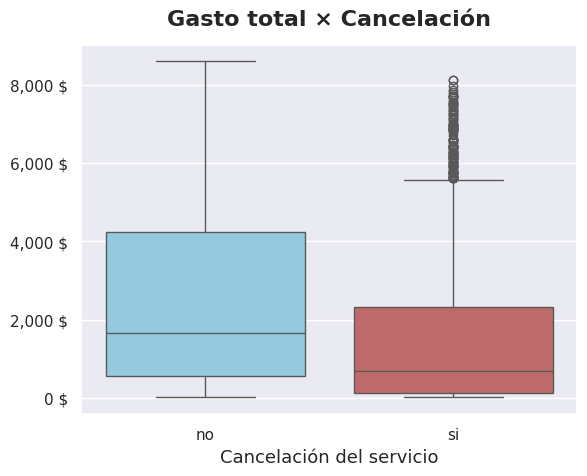

In [79]:
# Gráfico de Gasto total × Cancelación
sns.set()
ax = sns.boxplot(data=datos,
            x='abandono', y='cargo_total', hue='abandono', palette={'no':'skyblue', 'si':'indianred'})
plt.title('Gasto total × Cancelación', fontsize=16, fontweight='bold', y=1.03)
plt.xlabel('Cancelación del servicio', fontsize=13)
ax.set_ylabel('')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f} $"))
plt.show()

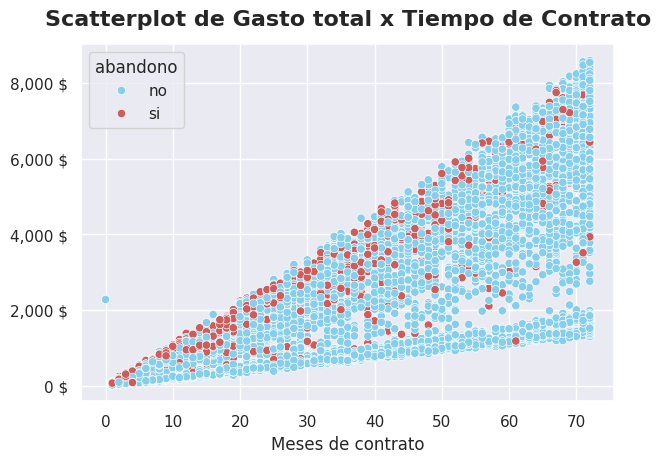

In [80]:
from matplotlib.ticker import FuncFormatter # librería para formatear ejes

# Gráfico de Scatterplot de gasto total y tiempo de contrato
sns.set()
ax = sns.scatterplot(data=datos, x='meses_de_contrato', y='cargo_total', hue='abandono', palette={'no':'skyblue', 'si':'indianred'})
plt.title('Scatterplot de Gasto total x Tiempo de Contrato', fontsize=16, fontweight='bold', y=1.03)
plt.xlabel('Meses de contrato')
ax.set_ylabel('')
# formatear eje y
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f} $"))
plt.tight_layout()
plt.show()

In [81]:
# correlación entre gasto total y tiempo de contrato
datos[['cargo_total', 'meses_de_contrato']].corr()

,cargo_total,meses_de_contrato
cargo_total,1.000000,0.823951
meses_de_contrato,0.823951,1.000000


* En el gráfico de dispersión, se observa que:
  * Existe una relación positiva fuerte entre meses de contrato y cargo total, es decir a medida que aumenta los meses de contrato, también aumenta el cargo total.
  * Además, se observa que clientes con contratos cortos proporcional su cargo total (cargo total bajo), están abandonando la empresa.
* En el gráfico de boxplot, se evidencia con claridad que:
  * La mayor cantidad de clientes que tienen un cargo total alto no están abandonando la empresa.

# 8. Balanceo de clases

## Verificación de la Proporción de Cancelación (Churn: abandono)

Se calcula qué porcentaje de clientes cancelaron el servicio en comparación con los que se mantuvieron activos. Esto permite identificar si hay un desbalance entre las clases (abandonan vs. no abandonan), lo cual es importante porque puede afectar el rendimiento y la interpretación de los modelos de predicción.

In [82]:
pd.Series(y).value_counts(normalize=True).round(3)*100

,proportion
0,74.4
1,25.6


* Clase 0: no abandona, con 74.4% del total de datos
* Clase 1: Abandona, con 25.6% del total de datos
  * Hay desbalance de clases, por lo que el paso siguiente es usar: **Undersampling** y **OverSampling**, para balancear las clases.

* Este desbalance puede llevar a que un modelo predictivo aprenda a favorecer la clase mayoritaria ("no abandono") y tenga un bajo desempeño al detectar casos de abandono, que normalmente son los más importantes para prevenir en un análisis de churn.

### Oversampling
* 👉 Aumentar la cantidad de ejemplos de la clase minoritaria para igualar (o acercarse) a la cantidad de la clase mayoritaria.
* Genera nuevos datos sintéticos, usa SMOTE(Synthetic Minority Over-sampling Technique)

### UnderSampling
* 👉Undersampling - Nearmiss: es un algoritmo que hace una reducción de muestras de forma inteligente de la clase mayoritaria para igualarla a la clase minoritaria

# 9. Modelado Predictivo

## 9.1. Creación de modelos
### 🔁 Pipelines con SMOTE y NearMiss
  * Modelos ML a usar:
    * Bosque Aleatorio (RandomForestClassifier)
    * KNN (KNeighborsClassifier)

In [83]:
# importar librerías necesarias
from imblearn.over_sampling import SMOTE  # remuestreo Oversampling
from imblearn.under_sampling import NearMiss  # remuestreo Undersampling
from imblearn.pipeline import Pipeline as ImbPipeline # pipeline: soporta para tratamiento de clases de desbalanceadas
from sklearn.ensemble import RandomForestClassifier # modelo bosquea aleatorio
from sklearn.neighbors import KNeighborsClassifier  # modelo KNN

# Modelos
modelo_knn = KNeighborsClassifier() # modelo de KNN
modelo_rf = RandomForestClassifier(max_depth=3, random_state=42)  # modelo de bosque aleatorio

# Pipeline con SMOTE
pipeline_smote_knn = ImbPipeline(steps=[
    ('preprocesador', preprocesador),   # transforma columnas numéricas y categóricas
    ('smote', SMOTE(random_state=42)),  # balance de clases
    ('modelo', modelo_knn)              # nodelo knn
])

pipeline_smote_rf = ImbPipeline(steps=[
    ('preprocesador', preprocesador),
    ('smote', SMOTE(random_state=42)),
    ('modelo', modelo_rf)
])

# Pipeline con NearMiss
pipeline_nm_knn = ImbPipeline(steps=[
    ('preprocessor', preprocesador),
    ('nearmiss', NearMiss(version=3)),
    ('model', modelo_knn)
])

pipeline_nm_rf = ImbPipeline(steps=[
    ('preprocessor', preprocesador),
    ('nearmiss', NearMiss(version=3)),
    ('model', modelo_rf)
])

## 9.2 Entrenamiento y Validación Cruzada en el conjunto de entrenamiento
* Usar `Validación Cruzada`: `cross_val_predict`
* Tipo de partición: `StratifiedKFold`

In [84]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report # resumen de métricas

# Dividir en 5 folds para entrenamiento y validación con StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipelines = {

        "SMOTE + KNN": pipeline_smote_knn,
        "SMOTE + RandomForest": pipeline_smote_rf,
        "NearMiss + KNN": pipeline_nm_knn,
        "NearMiss + RandomForest": pipeline_nm_rf

}

# iterar en cada modelo para obtener las métricas respectivas con validación cruzada(CV)
for nombre, pipe in pipelines.items():
  print(f'\🔎 Evaluando en datos de entrenamiento con Validación cruzada \n#### El modelo: {nombre}\n')
  print(f'-----------------------------------------------')

  # Predicción con CV y remuestreo dentro de cada fold
  y_predict_train = cross_val_predict(pipe, X,y, cv=skf)

  # Resultados
  print(classification_report(y, y_predict_train))

\🔎 Evaluando en datos de entrenamiento con Validación cruzada 
#### El modelo: SMOTE + KNN

-----------------------------------------------
              precision    recall  f1-score   support

           0       0.87      0.69      0.77      4323
           1       0.44      0.71      0.54      1488

    accuracy                           0.70      5811
   macro avg       0.66      0.70      0.66      5811
weighted avg       0.76      0.70      0.71      5811

\🔎 Evaluando en datos de entrenamiento con Validación cruzada 
#### El modelo: SMOTE + RandomForest

-----------------------------------------------
              precision    recall  f1-score   support

           0       0.92      0.70      0.79      4323
           1       0.48      0.82      0.61      1488

    accuracy                           0.73      5811
   macro avg       0.70      0.76      0.70      5811
weighted avg       0.81      0.73      0.75      5811

\🔎 Evaluando en datos de entrenamiento con Validación cru

## 9.3. Entrenamiento y Evaluación en el conjunto de prueba

In [85]:
# Paso 1: Definir nuevamente los pipelines

pipelines = {
    "SMOTE + KNN": pipeline_smote_knn,
    "SMOTE + RandomForest": pipeline_smote_rf,
    "NearMiss + KNN": pipeline_nm_knn,
    "NearMiss + RandomForest": pipeline_nm_rf
}

# Paso 2: Entrenar con los datos de entrenamiento y evaluar con el conjunto de prueba

for nombre, pipe in pipelines.items():
  print(f'\n🔎 Evaluando en datos de prueba: {nombre}')
  print('------------------------------------------------------')

  # Entrenar con todo el Set de entrenamiento
  pipe.fit(X,y)

  # Evaluar sobre el set de prueba
  y_predict_test = pipe.predict(X_test)

  # Resultados
  print(classification_report(y_test, y_predict_test))


🔎 Evaluando en datos de prueba: SMOTE + KNN
------------------------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.73      0.79      1073
           1       0.47      0.67      0.55       380

    accuracy                           0.72      1453
   macro avg       0.67      0.70      0.67      1453
weighted avg       0.76      0.72      0.73      1453


🔎 Evaluando en datos de prueba: SMOTE + RandomForest
------------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1073
           1       0.50      0.79      0.61       380

    accuracy                           0.74      1453
   macro avg       0.70      0.76      0.71      1453
weighted avg       0.80      0.74      0.75      1453


🔎 Evaluando en datos de prueba: NearMiss + KNN
------------------------------------------------------
              precision    recall 

## 9.4. Comparación visual entre train(CV) y test
* Resultados para informe

In [86]:
pipelines = {
    "SMOTE + KNN": pipeline_smote_knn,
    "SMOTE + RandomForest": pipeline_smote_rf,
    "NearMiss + KNN": pipeline_nm_knn,
    "NearMiss + RandomForest": pipeline_nm_rf
}

# Dividir en 5 folds para entrenamiento y validación con StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# librería para obtener las métricas por separado
from sklearn.metrics import precision_score, accuracy_score, f1_score, recall_score

# Amar un DataFrame con las métricas principales para datos de entrenamiento y prueba

resultados = [] #Df vacío, donde se almacenarán los resultados

for nombre, pipe in pipelines.items():

  ## ---Train con validación cruzada(CV)---
  y_cv_predict = cross_val_predict(pipe, X, y, cv = skf)
  resultados.append({
      'modelo': nombre,
      'fase': 'validación(CV)',
      'precision': precision_score(y, y_cv_predict),
      'recall': recall_score(y, y_cv_predict),
      'f1-score': f1_score(y, y_cv_predict),
      'accuracy': accuracy_score(y, y_cv_predict)

  })

  ## --Test--
  pipe.fit(X,y)
  y_test_predict = pipe.predict(X_test)
  resultados.append({
      'modelo': nombre,
      'fase': 'evaluación(test)',
      'precision': precision_score(y_test, y_test_predict),
      'recall': recall_score(y_test, y_test_predict),
      'f1-score': f1_score(y_test, y_test_predict),
      'accuracy': accuracy_score(y_test, y_test_predict)  # métrica no tan importante en datos desbalanceados
  })

# Mostrar los resultados en un DataFrame
resultados_modelos = pd.DataFrame(resultados).round(4)
resultados_modelos

,modelo,fase,precision,recall,f1-score,accuracy
0,SMOTE + KNN,validación(CV),0.4428,0.7070,0.5445,0.6971
1,SMOTE + KNN,evaluación(test),0.4689,0.6737,0.5529,0.7151
2,SMOTE + RandomForest,validación(CV),0.4826,0.8212,0.6080,0.7288
3,SMOTE + RandomForest,evaluación(test),0.4975,0.7947,0.6120,0.7364
4,NearMiss + KNN,validación(CV),0.4573,0.6015,0.5196,0.7152
5,NearMiss + KNN,evaluación(test),0.4383,0.5421,0.4847,0.6986
6,NearMiss + RandomForest,validación(CV),0.5504,0.6317,0.5882,0.7735
7,NearMiss + RandomForest,evaluación(test),0.5584,0.6421,0.5973,0.7736


## 9.5. Graficar resultados

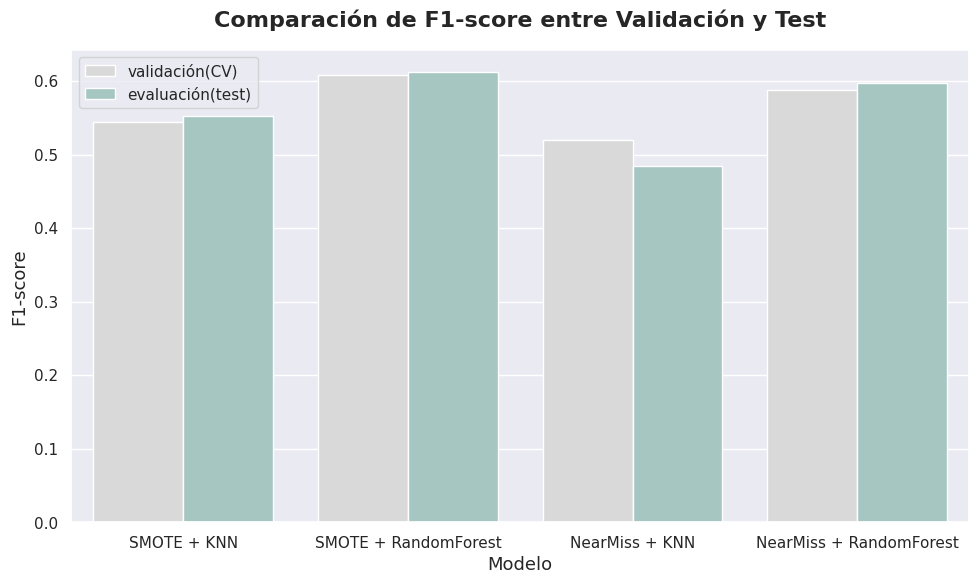

In [87]:
sns.set_style()
plt.figure(figsize=(10,6))
sns.barplot(data=resultados_modelos, x='modelo', y='f1-score',
            hue='fase', palette={'validación(CV)': GRIS_2, 'evaluación(test)': AQUA_2})
plt.title('Comparación de F1-score entre Validación y Test', fontsize=16, fontweight='bold', y=1.03)
plt.xlabel('Modelo', fontsize=13)
plt.ylabel('F1-score', fontsize=13)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

### ✅ Conclusión: Mejor modelo
🔍 **SMOTE + RandomForest** es la mejor opción, porque:
* **Prioriza recall: 0.79**(detectar abandonos reales).
  * Es crítico en este problema(es peor perder un cliente, que generar una falsa alarma).
* **Mejor F1-score: 0.61**
  * balance óptimo entre precisión y recall.
* **SMOTE** es más adecuado que NearMiss para éste caso, ya que no descarta información útil de la clase mayoritaria.
* **RandomForest** supera a KNN en robustez y capacidad para manejar relaciones no lineales en los datos.


# 10. Ajustar hiperparámetros del modelo RandomForest + SMOTE
* Usar: `GridSearchCV`

In [88]:
from sklearn.model_selection import GridSearchCV

# Definir el espacio de búsqueda
param_grid = {

              'modelo__n_estimators': [100, 200],
              'modelo__max_depth': [3, 5, 10],
              'modelo__min_samples_split': [2, 5],
              'modelo__min_samples_leaf': [1, 2]
}

# Instanciar StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# CV ajustando hiperparámetros con GridSearchCV
model_grid = GridSearchCV(pipeline_smote_rf,  # pipeline con modelo RandomForest + SMOTE
                          param_grid=param_grid,
                          scoring='f1',       # métrica principal a optimizar
                          cv=skf,             # CV stratificada con 5 folds
                          n_jobs=-1,          # Usa todos los núcleos disponibles, para probar combinaciones más rápido
                          verbose=0           # Por defecto 0, para producción, es ideal
)

# Entrenar el modelo
model_grid.fit(X,y)

# predecir: con el modelo entrenado
y_predict_grid = model_grid.predict(X_test)

# metricas
print(classification_report(y_test, y_predict_grid))

# ver los mejores parámetros
print('Mejores parámetros encontrados:\n')
print('-----------------------------------')
print(model_grid.best_params_)
print('-----------------------------------')
# El mejor modelo
mejor_modelo = model_grid.best_estimator_
print(f'El mejor modelo es:\n\n{mejor_modelo}')

              precision    recall  f1-score   support

           0       0.90      0.76      0.82      1073
           1       0.53      0.77      0.63       380

    accuracy                           0.76      1453
   macro avg       0.72      0.76      0.73      1453
weighted avg       0.81      0.76      0.77      1453

Mejores parámetros encontrados:

-----------------------------------
{'modelo__max_depth': 5, 'modelo__min_samples_leaf': 2, 'modelo__min_samples_split': 5, 'modelo__n_estimators': 100}
-----------------------------------
El mejor modelo es:

Pipeline(steps=[('preprocesador',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['meses_de_contrato',
                                                   'cargo_mensual',
                                                   'cargo_total',
                                                   'cuentas_diarias']),
                                           

📊 Métricas Clave

| Clase           | Precision | Recall | F1-Score | Interpretación                                                                 |
|----------------|-----------|--------|----------|--------------------------------------------------------------------------------|
| 0 (No abandono) | 0.90      | 0.76   | 0.82     | - Alta precisión: Pocos falsos positivos.<br>- Recall decente: Identifica el 76% de los clientes fieles. |
| 1 (Abandono)    | 0.53      | 0.77   | 0.63     | - Recall alto (77%): Detecta bien los abandonos reales.<br>- Precisión moderada (53%): Algunos falsos positivos (clientes predichos como abandonos que no lo son). |


🌟 Mejores Hiperparámetros Encontrados

| Hiperparámetro             | Valor | Descripción                                                                 |
|---------------------------|-------|-----------------------------------------------------------------------------|
| `modelo__max_depth`       | 5     | Profundidad máxima del árbol. Limita la complejidad del modelo y previene el sobreajuste. |
| `modelo__min_samples_leaf`| 2     | Número mínimo de muestras en una hoja. Permite suavizar las predicciones y evitar nodos con poca información. |
| `modelo__min_samples_split`| 5    | Número mínimo de muestras necesarias para dividir un nodo. Controla la formación de nuevas ramas. |
| `modelo__n_estimators`    | 100   | Número de árboles en el bosque. Aporta estabilidad al modelo sin aumentar mucho el tiempo de cómputo. |
